# Análise Exploratória de Contratos Públicos de Recife

Este notebook apresenta uma análise exploratória descritiva dos dados de contratos públicos da cidade do Recife/PE.

## Objetivos

1. Compreender a estrutura e qualidade dos dados
2. Analisar distribuições de valores contratuais
3. Investigar aspectos temporais dos contratos
4. Identificar principais fornecedores e órgãos contratantes
5. Detectar padrões e anomalias

## Metodologia

Seguiremos as melhores práticas de análise exploratória de dados (EDA):
- Análise univariada para entender cada variável individualmente
- Análise bivariada para explorar relações entre variáveis
- Visualizações claras e informativas
- Tratamento adequado de dados faltantes e inconsistentes

## 1. Configuração Inicial e Importação de Bibliotecas

In [7]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Configurações do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

# Suprimir avisos
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

Vamos carregar o dataset de contratos públicos de Recife. O arquivo está em formato CSV com separador de ponto e vírgula.

In [8]:
# Caminho do arquivo
data_path = '../../../data/pe/recife/dados_abertos_contratos.csv'

# Carregamento dos dados
df = pd.read_csv(data_path, sep=';', encoding='utf-8', low_memory=False)

print(f"Dataset carregado com sucesso!")
print(f"Dimensões: {df.shape[0]:,} linhas x {df.shape[1]} colunas")

Dataset carregado com sucesso!
Dimensões: 8,202 linhas x 20 colunas


## 3. Visão Geral dos Dados

### 3.1 Primeiras Linhas do Dataset

In [9]:
# Visualizar primeiras linhas
df.head(10)

,numerocontrato,anocontrato,orgaocontratante,objetocontrato,origemcontrato,sequencialcompra,cnpjcontratado,cpfcontratado,razaonomecontratado,logradouroendcontratado,numeroendcontratado,complementoendcontratado,bairroendcontratado,cidadeendcontratado,estadoendcontratado,datainiciovigencia,datafimvigencia,valorcontrato1,valorcontrato2,situacaocontrato
0,2901.0339/2004,"2,004.00",SECRETARIA DE ASSSTÊNCIA SOCIAL E COMBATE À FOME,"LOCAÇÃO DO IMÓVEL NÃO RESIDENCIAL, LOCALIZADO ...",DISPENSA,NaN,"12,859,864,000,142.00",NaN,CONSELHO PASTORAL DOS PESCADORES,NaN,NaN,NaN,NaN,NaN,NaN,2004/10/01 00:00:00.000,2004/12/31 00:00:00.000,"5,100.00","1,700.00",CADASTRADO
1,1401.0244/2007,"2,007.00",SECRETARIA DE EDUCAÇÃO,"A LOCAÇÃO DO IMÓVEL NÃO RESIDENCIAL, LOCALIZAD...",DISPENSA,NaN,NaN,"89,037,928,404.00",ANA CRISTINA SANTOS DE AZEVEDO,NaN,NaN,NaN,NaN,NaN,NaN,2007/11/01 00:00:00.000,2008/11/01 00:00:00.000,"5,400.00","5,400.00",CADASTRADO
2,2001.0171/2007,"2,007.00",SECRETARIA DE ORDEM PÚBLICA E SEGURANÇA,LOTAÇÃO DE IMÓVEL NÃO RESIDENCIAL SITUADO NA R...,DISPENSA,NaN,NaN,"8,399,832,472.00",JOÃO DIMAS DE BARROS,NaN,NaN,NaN,NaN,NaN,NaN,2007/07/05 00:00:00.000,2008/07/04 00:00:00.000,"173,684.71","12,000.00",CADASTRADO
3,2001.0221/2010,"2,010.00",SECRETARIA DE ORDEM PÚBLICA E SEGURANÇA,"LOCAÇÃO DE IMÓVEL NÃO RESIDENCIAL, SITUADO NA ...",DISPENSA,NaN,NaN,"31,614,744,491.00",ZUMIRA CELESTINA DE BARROS.,NaN,NaN,NaN,NaN,NaN,NaN,2010/12/23 00:00:00.000,2011/12/22 00:00:00.000,"54,267.89","7,344.00",CADASTRADO
4,6101.0001/2013,"2,013.00",AUTARQUIA MUNICIPAL DE PREVIDENCIA E ASSISTENC...,SERVIÇO DE GERENCIAMENTO DO ABASTECIMENTO DE C...,LICITAÇÃO,200.00,"8,201,104,000,176.00",NaN,PETROCARD ADMINISTRADORA DE CREDITO LTDA,RUA SENADOR JOSE HENRIQUE,224.00,ED. ALF. NOBEL 2203,ILHA DO LEITE,RECIFE,PE,2014/01/14 00:00:00.000,2015/01/13 00:00:00.000,"19,720.44","19,720.44",ENCERRADO
5,6101.0003/2013,"2,013.00",AUTARQUIA MUNICIPAL DE PREVIDENCIA E ASSISTENC...,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA NA PRESTA...,LICITAÇÃO,166.00,"42,035,097,000,207.00",NaN,GUARDSECURE SEGURANCA EMPRESARIAL LTDA,AVENIDA DA INTEGRACAO,927.00,LOTE 07 QDA E,VILA EDUARDO,PETROLINA,PE,2013/02/01 00:00:00.000,2014/02/10 00:00:00.000,"291,199.56","291,199.56",ENCERRADO
6,6101.0011/2013,"2,013.00",AUTARQUIA MUNICIPAL DE PREVIDENCIA E ASSISTENC...,CONTRATAÇÃO DE EMPRESA PARA PRESTAÇÃO DE SERVI...,LICITAÇÃO,"1,043.00","8,255,393,000,196.00",NaN,FOCO OPINIÃO E MERCADO LTDA EPP,RUA DAS ACACIAS,237.00,CASA,SACO DOS LIMOES,FLORIANOPOLIS,SC,2013/09/24 00:00:00.000,2014/09/23 00:00:00.000,"44,325.50","44,325.50",ENCERRADO
7,5010.6020/2013,"2,013.00",EMLURB - AUTARQUIA DE MANUTENÇÃO E LIMPEZA URBANA,SERVIÇOS COMPLEMENTARES DE LIMPEZA URBANA EM Á...,LICITAÇÃO,NaN,"40,884,405,000,154.00",NaN,LOQUIPE LOCACAO DE EQUIPAMENTOS E MAO DE OBRA ...,RUA MAJOR QUINTEIRO,89.00,NaN,CORDEIRO,RECIFE,PE,2013/06/17 00:00:00.000,2014/06/17 00:00:00.000,"10,729,487.95","9,149,891.20",ENCERRADO
8,1401.0041/2013,"2,013.00",SECRETARIA DE EDUCAÇÃO,CONTRATAÇÃO DE EMPRESA ESPECIALIZADA NA CONFEC...,LICITAÇÃO,284.00,"758,606,000,190.00",NaN,MXM GRAFICA E EMBALAGENS LTDA,AVENIDA CHICO SCIENCE,301.00,NaN,BULTRINS,OLINDA,PE,2013/04/16 00:00:00.000,2013/05/16 00:00:00.000,"15,210.00","15,210.00",CADASTRADO
9,1401.0042/2013,"2,013.00",SECRETARIA DE EDUCAÇÃO,"CONFECÇÃO DE MATERIAL GRÁFICA, LOTE II, DE ACO...",LICITAÇÃO,284.00,"7,211,171,000,109.00",NaN,JOYCE KAREN FRANCISCA DE MELO - ME,AVENIDA MANOLO CORTIZO,"5,327.00",NaN,CANDEIAS,JABOATAO DOS GUARARAPES,PE,2013/04/16 00:00:00.000,2013/07/15 00:00:00.000,"51,148.00","51,148.00",CADASTRADO


### 3.2 Estrutura e Tipos de Dados

In [10]:
# Informações sobre o dataset
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
df.info()

INFORMAÇÕES DO DATASET
<class 'pandas.DataFrame'>
RangeIndex: 8202 entries, 0 to 8201
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   numerocontrato            8202 non-null   str    
 1   anocontrato               6073 non-null   float64
 2   orgaocontratante          8202 non-null   str    
 3   objetocontrato            8199 non-null   str    
 4   origemcontrato            8202 non-null   str    
 5   sequencialcompra          5988 non-null   float64
 6   cnpjcontratado            7714 non-null   float64
 7   cpfcontratado             488 non-null    float64
 8   razaonomecontratado       8202 non-null   str    
 9   logradouroendcontratado   7740 non-null   str    
 10  numeroendcontratado       7547 non-null   float64
 11  complementoendcontratado  4363 non-null   str    
 12  bairroendcontratado       7729 non-null   str    
 13  cidadeendcontratado       7740 non-null   str    
 

In [11]:
# Lista de colunas
print("\nCOLUNAS DO DATASET")
print("=" * 80)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")


COLUNAS DO DATASET
 1. numerocontrato
 2. anocontrato
 3. orgaocontratante
 4. objetocontrato
 5. origemcontrato
 6. sequencialcompra
 7. cnpjcontratado
 8. cpfcontratado
 9. razaonomecontratado
10. logradouroendcontratado
11. numeroendcontratado
12. complementoendcontratado
13. bairroendcontratado
14. cidadeendcontratado
15. estadoendcontratado
16. datainiciovigencia
17. datafimvigencia
18. valorcontrato1
19. valorcontrato2
20. situacaocontrato


## 4. Análise de Qualidade dos Dados

### 4.1 Valores Ausentes

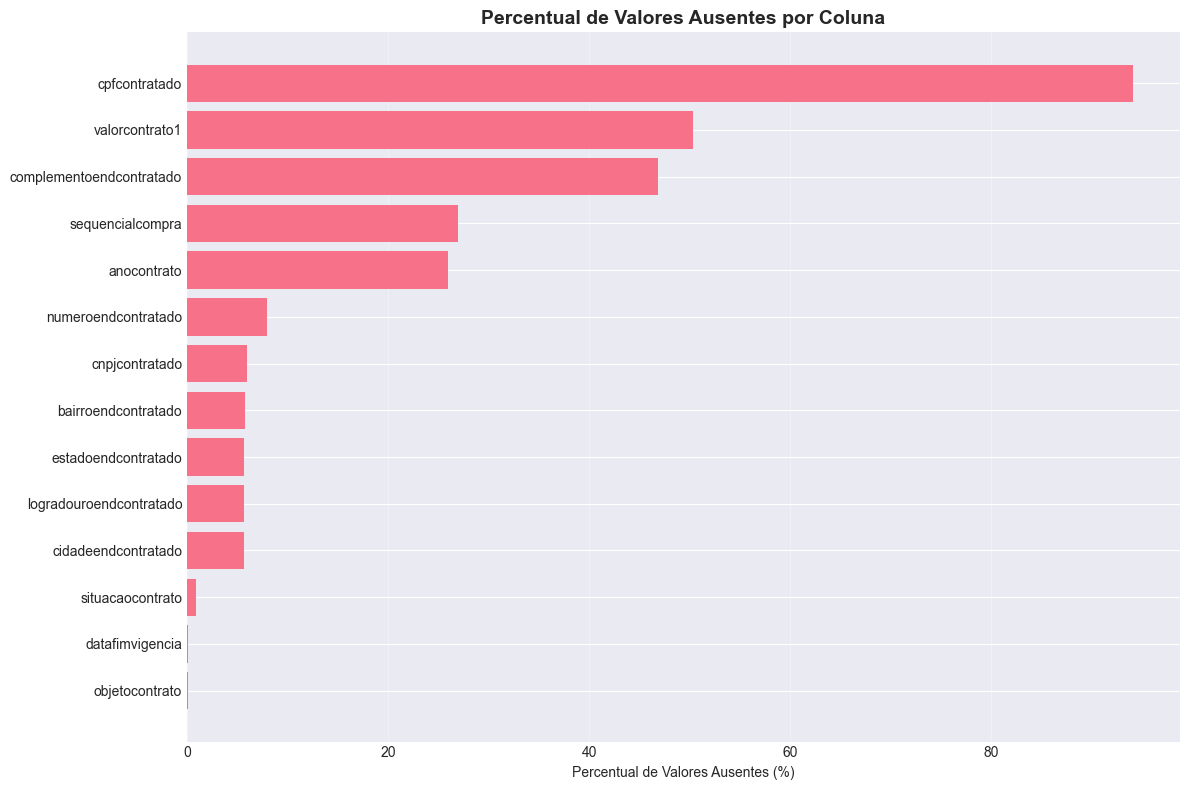

In [12]:
# Análise de valores ausentes
missing_data = pd.DataFrame({
    'Coluna': df.columns,
    'Total_Nulos': df.isnull().sum(),
    'Percentual_Nulos': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Total_Nulos', ascending=False)

print("ANÁLISE DE VALORES AUSENTES")
print("=" * 80)
print(missing_data[missing_data['Total_Nulos'] > 0])

# Visualização
fig, ax = plt.subplots(figsize=(12, 8))
missing_pct = missing_data[missing_data['Percentual_Nulos'] > 0].sort_values('Percentual_Nulos')
ax.barh(missing_pct['Coluna'], missing_pct['Percentual_Nulos'])
ax.set_xlabel('Percentual de Valores Ausentes (%)')
ax.set_title('Percentual de Valores Ausentes por Coluna', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Preparação e Limpeza dos Dados

In [13]:
# Criar cópia para trabalhar
df_clean = df.copy()

# Converter datas para formato datetime
date_columns = ['datainiciovigencia', 'datafimvigencia']
for col in date_columns:
    df_clean[col] = pd.to_datetime(df_clean[col], format='%Y/%m/%d %H:%M:%S.%f', errors='coerce')

# Garantir que valores numéricos estejam corretos
df_clean['valorcontrato1'] = pd.to_numeric(df_clean['valorcontrato1'], errors='coerce')
df_clean['valorcontrato2'] = pd.to_numeric(df_clean['valorcontrato2'], errors='coerce')

# Criar coluna de ano extraída da data de início
df_clean['ano_inicio'] = df_clean['datainiciovigencia'].dt.year

# Criar coluna de duração do contrato em dias
df_clean['duracao_dias'] = (df_clean['datafimvigencia'] - df_clean['datainiciovigencia']).dt.days

# Criar tipo de contratado (PJ ou PF)
df_clean['tipo_contratado'] = df_clean.apply(
    lambda x: 'Pessoa Jurídica' if pd.notna(x['cnpjcontratado']) else 
              ('Pessoa Física' if pd.notna(x['cpfcontratado']) else 'Não Identificado'),
    axis=1
)

print("Limpeza e preparação dos dados concluída!")
print(f"\nNovas colunas criadas: ano_inicio, duracao_dias, tipo_contratado")
print(f"Total de registros: {len(df_clean):,}")

Limpeza e preparação dos dados concluída!

Novas colunas criadas: ano_inicio, duracao_dias, tipo_contratado
Total de registros: 8,202


## 5. Estatísticas Descritivas Básicas

### 5.1 Resumo Estatístico de Variáveis Numéricas

In [14]:
# Estatísticas descritivas das variáveis numéricas principais
print("ESTATÍSTICAS DESCRITIVAS - VALORES CONTRATUAIS")
print("=" * 80)
numeric_cols = ['valorcontrato1', 'valorcontrato2', 'duracao_dias']
df_clean[numeric_cols].describe()

,valorcontrato1,valorcontrato2,duracao_dias
count,"4,079.00","8,202.00","8,195.00"
mean,"6,238,686.30","6,111,139.44",609.02
std,"240,266,896.33","210,350,886.73","11,074.20"
min,0.00,0.00,-216.00
25%,"30,029.00","50,000.00",241.00
50%,"133,208.40","159,689.10",364.00
75%,"628,535.58","776,129.67",365.00
max,"15,295,275,720.00","15,295,275,720.00","662,184.00"


### 5.2 Visão Geral dos Contratos

In [15]:
print("RESUMO GERAL DOS CONTRATOS")
print("=" * 80)
print(f"Total de contratos: {len(df_clean):,}")
print(f"\nPeríodo de análise:")
print(f"  - Ano mais antigo: {df_clean['anocontrato'].min()}")
print(f"  - Ano mais recente: {df_clean['anocontrato'].max()}")
print(f"\nValor total dos contratos:")
print(f"  - valorcontrato1: R$ {df_clean['valorcontrato1'].sum():,.2f}")
print(f"  - valorcontrato2: R$ {df_clean['valorcontrato2'].sum():,.2f}")
print(f"\nValor médio dos contratos:")
print(f"  - valorcontrato1: R$ {df_clean['valorcontrato1'].mean():,.2f}")
print(f"  - valorcontrato2: R$ {df_clean['valorcontrato2'].mean():,.2f}")
print(f"\nTipo de contratado:")
print(df_clean['tipo_contratado'].value_counts())
print(f"\nSituação dos contratos:")
print(df_clean['situacaocontrato'].value_counts())

RESUMO GERAL DOS CONTRATOS
Total de contratos: 8,202

Período de análise:
  - Ano mais antigo: 2004.0
  - Ano mais recente: 2026.0

Valor total dos contratos:
  - valorcontrato1: R$ 25,447,601,407.64
  - valorcontrato2: R$ 50,123,565,657.72

Valor médio dos contratos:
  - valorcontrato1: R$ 6,238,686.30
  - valorcontrato2: R$ 6,111,139.44

Tipo de contratado:
tipo_contratado
Pessoa Jurídica    7714
Pessoa Física       488
Name: count, dtype: int64

Situação dos contratos:
situacaocontrato
CADASTRADO    6488
ENCERRADO     1611
CANCELADO       31
Name: count, dtype: int64


## 6. Análise de Distribuição de Valores

### 6.1 Distribuição de Valores Contratuais

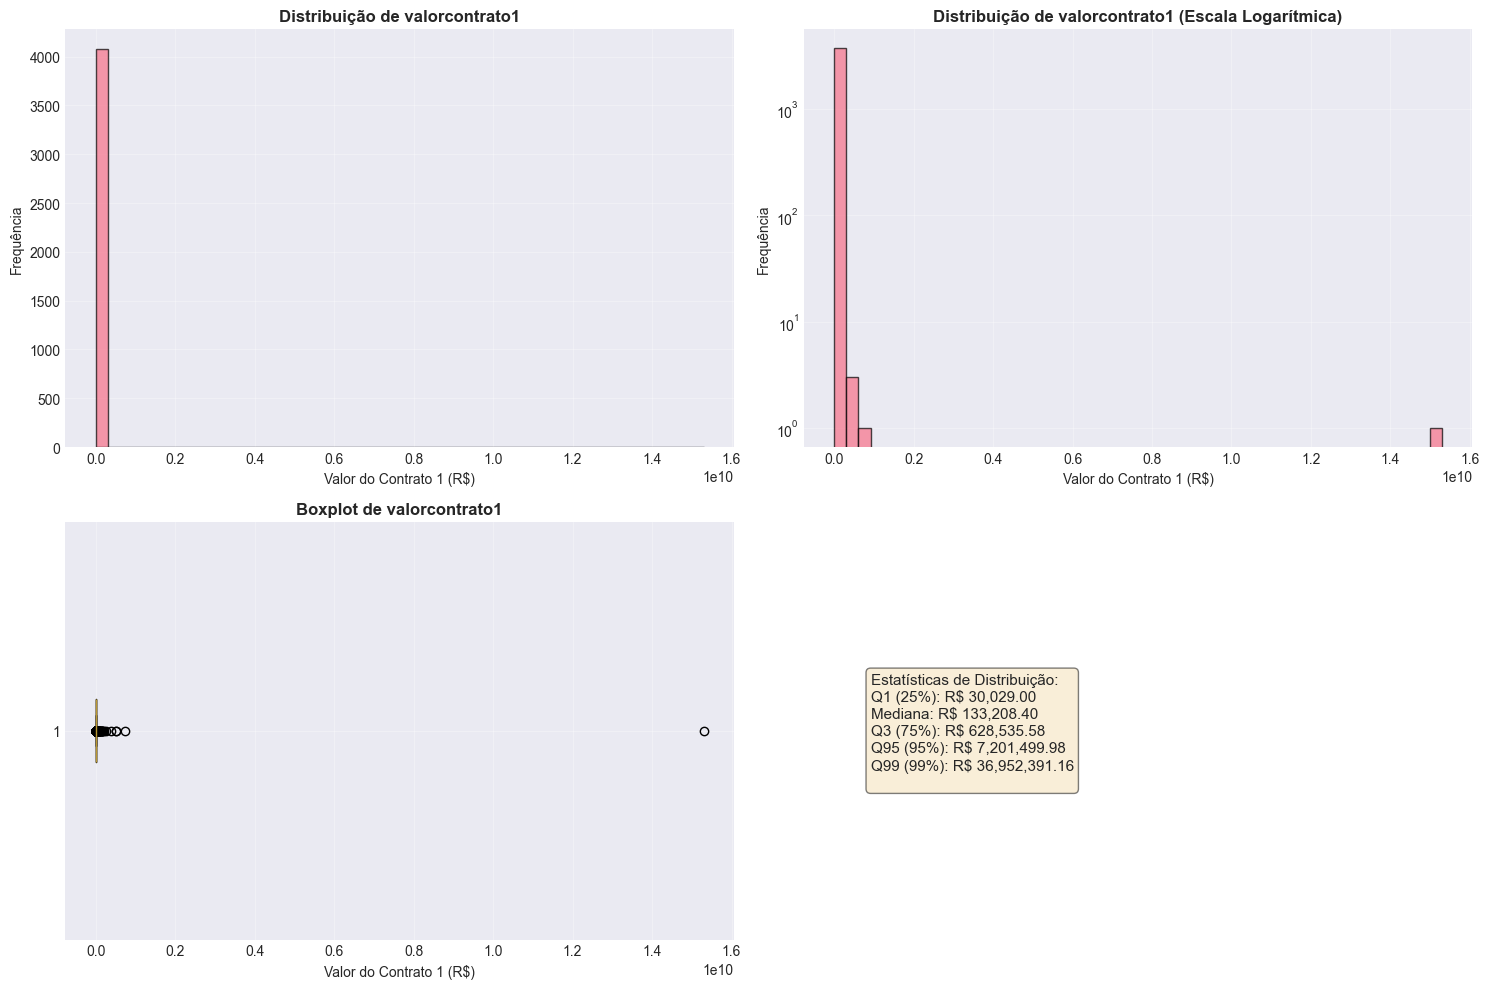

In [16]:
# Análise da distribuição de valores
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histograma de valorcontrato1
axes[0, 0].hist(df_clean['valorcontrato1'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Valor do Contrato 1 (R$)')
axes[0, 0].set_ylabel('Frequência')
axes[0, 0].set_title('Distribuição de valorcontrato1', fontweight='bold')
axes[0, 0].grid(alpha=0.3)

# Histograma de valorcontrato1 (escala log)
axes[0, 1].hist(df_clean[df_clean['valorcontrato1'] > 0]['valorcontrato1'], 
                bins=50, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Valor do Contrato 1 (R$)')
axes[0, 1].set_ylabel('Frequência')
axes[0, 1].set_title('Distribuição de valorcontrato1 (Escala Logarítmica)', fontweight='bold')
axes[0, 1].set_yscale('log')
axes[0, 1].grid(alpha=0.3)

# Boxplot de valorcontrato1
axes[1, 0].boxplot(df_clean['valorcontrato1'].dropna(), vert=False)
axes[1, 0].set_xlabel('Valor do Contrato 1 (R$)')
axes[1, 0].set_title('Boxplot de valorcontrato1', fontweight='bold')
axes[1, 0].grid(alpha=0.3)

# Estatísticas de quartis
q1 = df_clean['valorcontrato1'].quantile(0.25)
median = df_clean['valorcontrato1'].median()
q3 = df_clean['valorcontrato1'].quantile(0.75)
q95 = df_clean['valorcontrato1'].quantile(0.95)
q99 = df_clean['valorcontrato1'].quantile(0.99)

stats_text = f"""Estatísticas de Distribuição:
Q1 (25%): R$ {q1:,.2f}
Mediana: R$ {median:,.2f}
Q3 (75%): R$ {q3:,.2f}
Q95 (95%): R$ {q95:,.2f}
Q99 (99%): R$ {q99:,.2f}
"""

axes[1, 1].text(0.1, 0.5, stats_text, transform=axes[1, 1].transAxes,
                fontsize=11, verticalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

### 6.2 Maiores Contratos

In [17]:
# Top 20 maiores contratos
print("TOP 20 MAIORES CONTRATOS (valorcontrato1)")
print("=" * 80)
top_contracts = df_clean.nlargest(20, 'valorcontrato1')[[
    'numerocontrato', 'anocontrato', 'orgaocontratante', 'razaonomecontratado',
    'valorcontrato1', 'situacaocontrato'
]]
display(top_contracts)

,numerocontrato,anocontrato,orgaocontratante,razaonomecontratado,valorcontrato1,situacaocontrato
3779,3101.1007/2023,"2,023.00",SECRETARIA DE DESENVOLVIMENTO URBANO E LICENCI...,AGENCIA RECIFE PARA INOVACAO E ESTRATEGIA - ARIES,"15,295,275,720.00",CADASTRADO
328,5010.6023/2015,"2,016.00",EMLURB - AUTARQUIA DE MANUTENÇÃO E LIMPEZA URBANA,VITAL ENGENHARIA AMBIENTAL S/A,"729,976,268.81",CADASTRADO
6267,5002.6016/2010,NaN,EMLURB - AUTARQUIA DE MANUTENÇÃO E LIMPEZA URBANA,VITAL ENGENHARIA AMBIENTAL S/A,"513,549,163.68",CADASTRADO
1778,3501.0021/2020,"2,020.00",SECRETARIA DE TURISMO E LAZER,INSTITUTO DE GESTAO DE ESPORTE E DA CULTURA - ...,"506,937,289.84",ENCERRADO
6744,4101.0009/2014,NaN,GINÁSIO DE ESPORTES GERALDO MAGALHAES - GERALDAO,SOLL SERVICOS OBRAS E LOCACOES LTDA,"375,822,720.00",CADASTRADO
329,5010.6024/2015,"2,016.00",EMLURB - AUTARQUIA DE MANUTENÇÃO E LIMPEZA URBANA,COELHO DE ANDRADE ENGENHARIA LTDA,"249,839,914.00",CADASTRADO
2722,2101.1007/2022,"2,022.00",SECRETARIA DE DESENVOLVIMENTO URBANO E LICENCI...,ELETROMIDIA REC CONCESSIONARIA DE MOBILIARIO U...,"212,649,536.36",CADASTRADO
7122,3201.0260/2014,NaN,SECRETARIA DE CULTURA,AJ SERVICOS DE MAO DE OBRA EIRELI,"185,762,244.00",CADASTRADO
7090,3201.0041/2012,NaN,SECRETARIA DE CULTURA,ENGEMAR CONSTRUCOES SERVICOS LTDA,"165,998,440.00",CADASTRADO
8189,5006.0047/2011,NaN,URB - AUTARQUIA DE URBANIZACAO DO RECIFE,LOQUIPE LOCACAO DE EQUIPAMENTOS E MAO DE OBRA ...,"162,840,000.00",CADASTRADO


## 7. Análise Temporal dos Contratos

### 7.1 Distribuição de Contratos por Ano

In [18]:
# Análise temporal
contracts_by_year = df_clean.groupby('anocontrato').agg({
    'numerocontrato': 'count',
    'valorcontrato1': 'sum',
    'valorcontrato2': 'sum'
}).rename(columns={'numerocontrato': 'quantidade'})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Quantidade de contratos por ano
axes[0].bar(contracts_by_year.index, contracts_by_year['quantidade'], 
            edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('Quantidade de Contratos')
axes[0].set_title('Quantidade de Contratos por Ano', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# Valor total por ano
axes[1].bar(contracts_by_year.index, contracts_by_year['valorcontrato1'], 
            edgecolor='black', alpha=0.7, color='coral')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Valor Total (R$)')
axes[1].set_title('Valor Total de Contratos por Ano', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nRESUMO POR ANO")
print("=" * 80)
display(contracts_by_year)

,quantidade,valorcontrato1,valorcontrato2
anocontrato,,,
"2,004.00",1,"5,100.00","1,700.00"
"2,007.00",2,"179,084.71","17,400.00"
"2,010.00",1,"54,267.89","7,344.00"
"2,013.00",7,"13,187,100.93","9,657,894.70"
"2,014.00",131,"41,025,601.73","41,025,601.73"
"2,015.00",137,"81,661,680.94","114,278,365.71"
"2,016.00",167,"1,081,409,591.40","1,085,621,868.25"
"2,017.00",150,"112,081,104.22","141,342,841.64"
"2,018.00",328,"231,544,560.35","379,291,460.42"


### 7.2 Análise de Duração dos Contratos

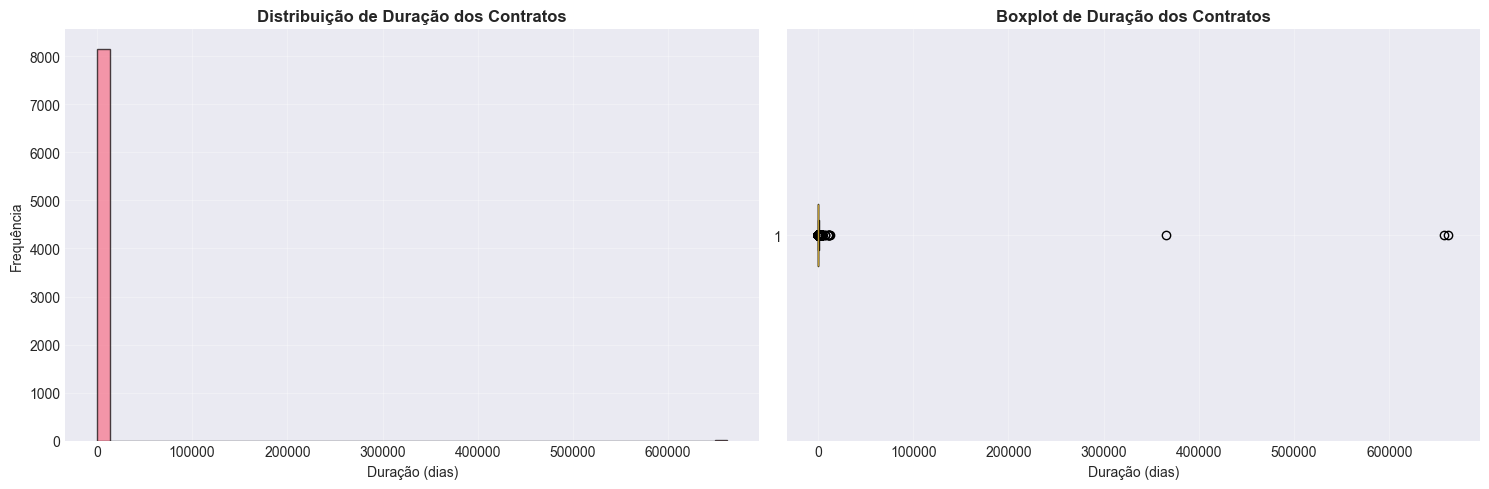

In [19]:
# Análise de duração
df_duration = df_clean[df_clean['duracao_dias'].notna() & (df_clean['duracao_dias'] > 0)]

print("ESTATÍSTICAS DE DURAÇÃO DOS CONTRATOS")
print("=" * 80)
print(f"Média: {df_duration['duracao_dias'].mean():.0f} dias")
print(f"Mediana: {df_duration['duracao_dias'].median():.0f} dias")
print(f"Mínimo: {df_duration['duracao_dias'].min():.0f} dias")
print(f"Máximo: {df_duration['duracao_dias'].max():.0f} dias")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de duração
axes[0].hist(df_duration['duracao_dias'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Duração (dias)')
axes[0].set_ylabel('Frequência')
axes[0].set_title('Distribuição de Duração dos Contratos', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3)

# Boxplot de duração
axes[1].boxplot(df_duration['duracao_dias'], vert=False)
axes[1].set_xlabel('Duração (dias)')
axes[1].set_title('Boxplot de Duração dos Contratos', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análise por Origem e Tipo de Contrato

### 8.1 Distribuição por Origem do Contrato

In [20]:
# Análise por origem
origin_analysis = df_clean.groupby('origemcontrato').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean']
}).round(2)
origin_analysis.columns = ['Quantidade', 'Valor_Total', 'Valor_Medio']
origin_analysis = origin_analysis.sort_values('Quantidade', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico de pizza - quantidade
axes[0].pie(origin_analysis['Quantidade'], labels=origin_analysis.index, 
            autopct='%1.1f%%', startangle=90)
axes[0].set_title('Distribuição de Contratos por Origem', fontsize=12, fontweight='bold')

# Gráfico de barras - valor total
axes[1].barh(origin_analysis.index, origin_analysis['Valor_Total'], alpha=0.7)
axes[1].set_xlabel('Valor Total (R$)')
axes[1].set_title('Valor Total por Origem de Contrato', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRESUMO POR ORIGEM DE CONTRATO")
print("=" * 80)
display(origin_analysis)

,Quantidade,Valor_Total,Valor_Medio
origemcontrato,,,
SARP,3090,"2,121,347,404.38","1,343,475.24"
LICITAÇÃO,2477,"7,006,927,725.11","4,552,909.50"
INEXIGIBILIDADE,1746,"15,615,685,095.54","43,376,903.04"
DISPENSA,852,"694,008,588.76","1,224,001.04"
COMPRA DIRETA,37,"9,632,593.85","283,311.58"


## 9. Análise de Fornecedores

### 9.1 Principais Fornecedores

In [21]:
# Top fornecedores por quantidade
top_suppliers_qty = df_clean.groupby('razaonomecontratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': 'sum'
}).rename(columns={
    'numerocontrato': 'Quantidade_Contratos',
    'valorcontrato1': 'Valor_Total'
}).sort_values('Quantidade_Contratos', ascending=False).head(20)

# Top fornecedores por valor
top_suppliers_value = df_clean.groupby('razaonomecontratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': 'sum'
}).rename(columns={
    'numerocontrato': 'Quantidade_Contratos',
    'valorcontrato1': 'Valor_Total'
}).sort_values('Valor_Total', ascending=False).head(20)

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Top por quantidade
axes[0].barh(range(len(top_suppliers_qty)), top_suppliers_qty['Quantidade_Contratos'], alpha=0.7)
axes[0].set_yticks(range(len(top_suppliers_qty)))
axes[0].set_yticklabels(top_suppliers_qty.index, fontsize=9)
axes[0].set_xlabel('Quantidade de Contratos')
axes[0].set_title('Top 20 Fornecedores por Quantidade de Contratos', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Top por valor
axes[1].barh(range(len(top_suppliers_value)), top_suppliers_value['Valor_Total'], 
             alpha=0.7, color='coral')
axes[1].set_yticks(range(len(top_suppliers_value)))
axes[1].set_yticklabels(top_suppliers_value.index, fontsize=9)
axes[1].set_xlabel('Valor Total (R$)')
axes[1].set_title('Top 20 Fornecedores por Valor Total Contratado', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTOP 20 FORNECEDORES POR QUANTIDADE")
print("=" * 80)
display(top_suppliers_qty)

print("\nTOP 20 FORNECEDORES POR VALOR TOTAL")
print("=" * 80)
display(top_suppliers_value)

,Quantidade_Contratos,Valor_Total
razaonomecontratado,,
AGENCIA RECIFE PARA INOVACAO E ESTRATEGIA - ARIES,1,"15,295,275,720.00"
VITAL ENGENHARIA AMBIENTAL S/A,3,"1,243,525,432.49"
INSTITUTO DE GESTAO DE ESPORTE E DA CULTURA - IGEC,6,"544,682,582.30"
SOLL SERVICOS OBRAS E LOCACOES LTDA,47,"537,634,273.48"
LOQUIPE LOCACAO DE EQUIPAMENTOS E MAO DE OBRA LTDA,64,"457,477,270.46"
COELHO DE ANDRADE ENGENHARIA LTDA,5,"438,212,416.64"
AJ SERVICOS DE MAO DE OBRA EIRELI,36,"259,942,569.42"
R P L ENGENHARIA E SERVICOS LTDA,177,"240,615,301.10"
ELETROMIDIA REC CONCESSIONARIA DE MOBILIARIO URBANO SPE S.A.,1,"212,649,536.36"


### 9.2 Concentração de Fornecedores

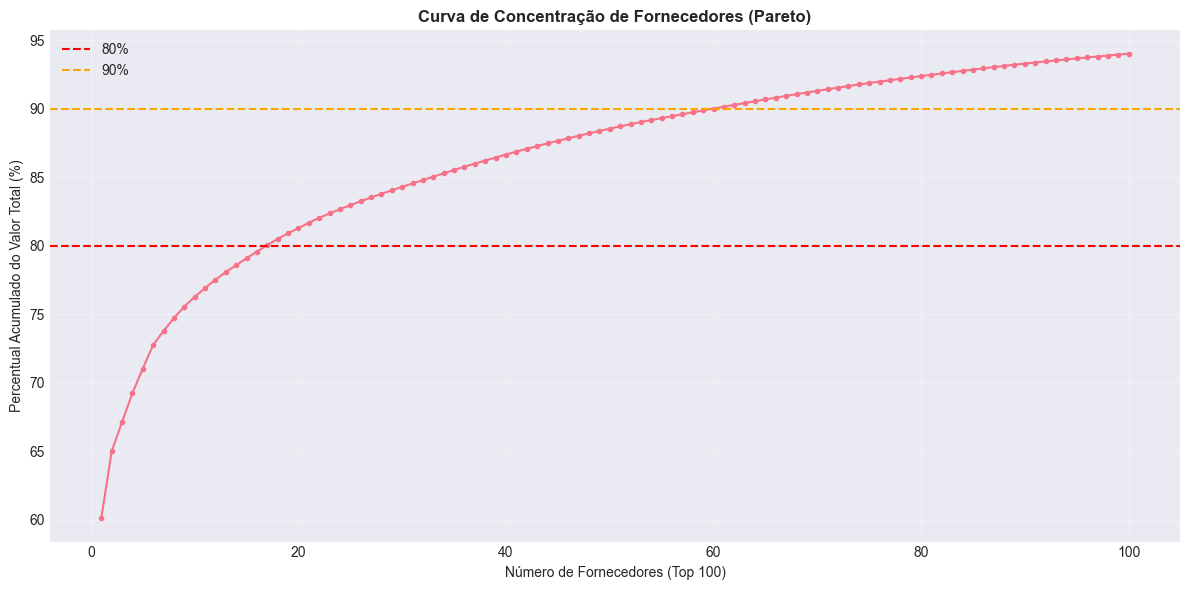

In [22]:
# Análise de concentração
supplier_stats = df_clean.groupby('razaonomecontratado')['valorcontrato1'].sum().sort_values(ascending=False)
total_value = supplier_stats.sum()
cumulative_pct = (supplier_stats.cumsum() / total_value * 100)

# Identificar quantos fornecedores representam 80% do valor
suppliers_80pct = (cumulative_pct <= 80).sum()
suppliers_90pct = (cumulative_pct <= 90).sum()

print("ANÁLISE DE CONCENTRAÇÃO DE FORNECEDORES")
print("=" * 80)
print(f"Total de fornecedores únicos: {len(supplier_stats):,}")
print(f"\nConcentração de mercado:")
print(f"  - {suppliers_80pct} fornecedores ({suppliers_80pct/len(supplier_stats)*100:.1f}%) representam 80% do valor total")
print(f"  - {suppliers_90pct} fornecedores ({suppliers_90pct/len(supplier_stats)*100:.1f}%) representam 90% do valor total")

# Curva de Pareto
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(range(1, len(cumulative_pct[:100])+1), cumulative_pct[:100], marker='o', markersize=3)
ax.axhline(y=80, color='r', linestyle='--', label='80%')
ax.axhline(y=90, color='orange', linestyle='--', label='90%')
ax.set_xlabel('Número de Fornecedores (Top 100)')
ax.set_ylabel('Percentual Acumulado do Valor Total (%)')
ax.set_title('Curva de Concentração de Fornecedores (Pareto)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Análise de Órgãos Contratantes

### 10.1 Principais Órgãos Contratantes

In [23]:
# Análise de órgãos contratantes
top_agencies = df_clean.groupby('orgaocontratante').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean']
}).round(2)
top_agencies.columns = ['Quantidade', 'Valor_Total', 'Valor_Medio']
top_agencies = top_agencies.sort_values('Valor_Total', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Valor total por órgão
axes[0].barh(range(len(top_agencies)), top_agencies['Valor_Total'], alpha=0.7)
axes[0].set_yticks(range(len(top_agencies)))
axes[0].set_yticklabels(top_agencies.index, fontsize=8)
axes[0].set_xlabel('Valor Total (R$)')
axes[0].set_title('Top 15 Órgãos por Valor Total', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)
axes[0].invert_yaxis()

# Quantidade de contratos por órgão
axes[1].barh(range(len(top_agencies)), top_agencies['Quantidade'], alpha=0.7, color='green')
axes[1].set_yticks(range(len(top_agencies)))
axes[1].set_yticklabels(top_agencies.index, fontsize=8)
axes[1].set_xlabel('Quantidade de Contratos')
axes[1].set_title('Top 15 Órgãos por Quantidade de Contratos', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("\nTOP 15 ÓRGÃOS CONTRATANTES")
print("=" * 80)
display(top_agencies)

,Quantidade,Valor_Total,Valor_Medio
orgaocontratante,,,
SECRETARIA DE DESENVOLVIMENTO URBANO E LICENCIAMENTO,146,"15,557,593,473.05","163,764,141.82"
EMLURB - AUTARQUIA DE MANUTENÇÃO E LIMPEZA URBANA,994,"3,333,140,878.25","5,290,699.81"
SECRETARIA DE EDUCAÇÃO,860,"1,146,646,947.55","2,325,855.88"
SECRETARIA DE TURISMO E LAZER,294,"689,701,277.02","3,397,543.24"
FUNDO MUNICIPAL DE SAUDE,522,"649,574,640.93","2,547,351.53"
SECRETARIA DE SANEAMENTO,119,"591,306,698.30","8,212,593.03"
URB - AUTARQUIA DE URBANIZACAO DO RECIFE,200,"520,983,359.69","12,706,911.21"
SECRETARIA DE CULTURA,99,"441,166,754.06","5,190,197.11"
GINÁSIO DE ESPORTES GERALDO MAGALHAES - GERALDAO,29,"388,547,077.89","13,398,175.10"


## 11. Análise de Situação dos Contratos

In [24]:
# Análise por situação
status_analysis = df_clean.groupby('situacaocontrato').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean']
}).round(2)
status_analysis.columns = ['Quantidade', 'Valor_Total', 'Valor_Medio']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico de pizza
colors = plt.cm.Paired(range(len(status_analysis)))
axes[0].pie(status_analysis['Quantidade'], labels=status_analysis.index, 
            autopct='%1.1f%%', startangle=90, colors=colors)
axes[0].set_title('Distribuição por Situação do Contrato', fontsize=12, fontweight='bold')

# Gráfico de barras
axes[1].bar(status_analysis.index, status_analysis['Quantidade'], 
            alpha=0.7, color=colors, edgecolor='black')
axes[1].set_ylabel('Quantidade de Contratos')
axes[1].set_title('Quantidade de Contratos por Situação', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRESUMO POR SITUAÇÃO DO CONTRATO")
print("=" * 80)
display(status_analysis)

,Quantidade,Valor_Total,Valor_Medio
situacaocontrato,,,
CADASTRADO,6488,"22,254,638,146.34","8,394,808.81"
CANCELADO,31,"38,659,637.50","1,333,090.95"
ENCERRADO,1611,"3,154,303,623.80","2,254,684.51"


## 12. Análise por Tipo de Contratado (PJ vs PF)

In [25]:
# Análise PJ vs PF
type_analysis = df_clean.groupby('tipo_contratado').agg({
    'numerocontrato': 'count',
    'valorcontrato1': ['sum', 'mean', 'median']
}).round(2)
type_analysis.columns = ['Quantidade', 'Valor_Total', 'Valor_Medio', 'Valor_Mediano']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Quantidade
axes[0].bar(type_analysis.index, type_analysis['Quantidade'], alpha=0.7, edgecolor='black')
axes[0].set_ylabel('Quantidade de Contratos')
axes[0].set_title('Quantidade por Tipo de Contratado', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(axis='y', alpha=0.3)

# Valor total
axes[1].bar(type_analysis.index, type_analysis['Valor_Total'], 
            alpha=0.7, color='coral', edgecolor='black')
axes[1].set_ylabel('Valor Total (R$)')
axes[1].set_title('Valor Total por Tipo de Contratado', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', alpha=0.3)

# Valor médio
axes[2].bar(type_analysis.index, type_analysis['Valor_Medio'], 
            alpha=0.7, color='green', edgecolor='black')
axes[2].set_ylabel('Valor Médio (R$)')
axes[2].set_title('Valor Médio por Tipo de Contratado', fontsize=12, fontweight='bold')
axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nRESUMO POR TIPO DE CONTRATADO")
print("=" * 80)
display(type_analysis)

,Quantidade,Valor_Total,Valor_Medio,Valor_Mediano
tipo_contratado,,,,
Pessoa Física,488,"24,901,878.29","88,618.78","18,000.00"
Pessoa Jurídica,7714,"25,422,699,529.35","6,693,707.09","149,925.00"


## 13. Principais Insights e Conclusões

### 13.1 Síntese da Análise

In [26]:
print("PRINCIPAIS INSIGHTS DA ANÁLISE")
print("=" * 80)
print("\n1. VOLUME DE DADOS:")
print(f"   - Total de contratos analisados: {len(df_clean):,}")
print(f"   - Período: {df_clean['anocontrato'].min()} a {df_clean['anocontrato'].max()}")
print(f"   - Valor total acumulado: R$ {df_clean['valorcontrato1'].sum():,.2f}")

print("\n2. DISTRIBUIÇÃO DE VALORES:")
print(f"   - Valor médio dos contratos: R$ {df_clean['valorcontrato1'].mean():,.2f}")
print(f"   - Valor mediano: R$ {df_clean['valorcontrato1'].median():,.2f}")
print(f"   - Maior contrato: R$ {df_clean['valorcontrato1'].max():,.2f}")
print(f"   - Menor contrato: R$ {df_clean['valorcontrato1'].min():,.2f}")

print("\n3. CONCENTRAÇÃO:")
print(f"   - Fornecedores únicos: {df_clean['razaonomecontratado'].nunique():,}")
print(f"   - Órgãos contratantes únicos: {df_clean['orgaocontratante'].nunique():,}")
supplier_stats = df_clean.groupby('razaonomecontratado')['valorcontrato1'].sum().sort_values(ascending=False)
total_value = supplier_stats.sum()
cumulative_pct = (supplier_stats.cumsum() / total_value * 100)
suppliers_80pct = (cumulative_pct <= 80).sum()
print(f"   - {suppliers_80pct} fornecedores concentram 80% do valor")

print("\n4. ORIGEM DOS CONTRATOS:")
origin_top = df_clean['origemcontrato'].value_counts().head(1)
print(f"   - Origem mais comum: {origin_top.index[0]} ({origin_top.values[0]:,} contratos)")

print("\n5. SITUAÇÃO:")
status_counts = df_clean['situacaocontrato'].value_counts()
for status, count in status_counts.items():
    pct = count / len(df_clean) * 100
    print(f"   - {status}: {count:,} ({pct:.1f}%)")

print("\n6. TIPO DE CONTRATADO:")
type_counts = df_clean['tipo_contratado'].value_counts()
for tipo, count in type_counts.items():
    pct = count / len(df_clean) * 100
    print(f"   - {tipo}: {count:,} ({pct:.1f}%)")

print("\n7. DURAÇÃO:")
df_duration = df_clean[df_clean['duracao_dias'].notna() & (df_clean['duracao_dias'] > 0)]
print(f"   - Duração média: {df_duration['duracao_dias'].mean():.0f} dias")
print(f"   - Duração mediana: {df_duration['duracao_dias'].median():.0f} dias")

PRINCIPAIS INSIGHTS DA ANÁLISE

1. VOLUME DE DADOS:
   - Total de contratos analisados: 8,202
   - Período: 2004.0 a 2026.0
   - Valor total acumulado: R$ 25,447,601,407.64

2. DISTRIBUIÇÃO DE VALORES:
   - Valor médio dos contratos: R$ 6,238,686.30
   - Valor mediano: R$ 133,208.40
   - Maior contrato: R$ 15,295,275,720.00
   - Menor contrato: R$ 0.00

3. CONCENTRAÇÃO:
   - Fornecedores únicos: 2,544
   - Órgãos contratantes únicos: 57
   - 16 fornecedores concentram 80% do valor

4. ORIGEM DOS CONTRATOS:
   - Origem mais comum: SARP (3,090 contratos)

5. SITUAÇÃO:
   - CADASTRADO: 6,488 (79.1%)
   - ENCERRADO: 1,611 (19.6%)
   - CANCELADO: 31 (0.4%)

6. TIPO DE CONTRATADO:
   - Pessoa Jurídica: 7,714 (94.1%)
   - Pessoa Física: 488 (5.9%)

7. DURAÇÃO:
   - Duração média: 612 dias
   - Duração mediana: 364 dias


### 13.2 Recomendações para Análises Futuras

Com base nesta análise exploratória, sugerimos as seguintes investigações adicionais:

1. **Análise de Anomalias**: Investigar contratos com valores muito acima ou abaixo da média para identificar possíveis outliers ou padrões incomuns

2. **Análise Temporal Avançada**: 
   - Estudar sazonalidade nos contratos
   - Analisar tendências de crescimento/decrescimento ao longo dos anos
   - Verificar padrões de renovação

3. **Análise de Relacionamentos**:
   - Mapear redes de fornecedores e órgãos
   - Identificar fornecedores que atuam em múltiplos órgãos

4. **Análise de Eficiência**:
   - Comparar valores médios entre diferentes modalidades de contratação
   - Avaliar a relação entre duração e valor dos contratos

5. **Análise Geográfica**:
   - Mapear distribuição geográfica dos fornecedores
   - Analisar se há concentração regional

6. **Análise Textual**:
   - Processar textos dos objetos contratuais para categorização automática
   - Identificar temas e assuntos mais frequentes

7. **Modelagem Preditiva**:
   - Prever valores de contratos com base em características
   - Classificar tipos de contratos automaticamente
   - Detectar anomalias usando machine learning

## 14. Exportação de Resultados

Salvando dataset limpo e estatísticas principais para uso futuro.

In [28]:
# Salvar dataset limpo
output_path = '../../../data/pe/recife/dados_abertos_contratos_limpo.csv'
df_clean.to_csv(output_path, index=False, encoding='utf-8', sep=';')
print(f"Dataset limpo salvo em: {output_path}")

# Salvar estatísticas principais
stats_summary = {
    'total_contratos': len(df_clean),
    'valor_total': df_clean['valorcontrato1'].sum(),
    'valor_medio': df_clean['valorcontrato1'].mean(),
    'valor_mediano': df_clean['valorcontrato1'].median(),
    'periodo_inicio': df_clean['anocontrato'].min(),
    'periodo_fim': df_clean['anocontrato'].max(),
    'fornecedores_unicos': df_clean['razaonomecontratado'].nunique(),
    'orgaos_unicos': df_clean['orgaocontratante'].nunique()
}

print("\nESTATÍSTICAS PRINCIPAIS EXPORTADAS")
print("=" * 80)
for key, value in stats_summary.items():
    print(f"{key}: {value}")

Dataset limpo salvo em: ../../../data/pe/recife/dados_abertos_contratos_limpo.csv

ESTATÍSTICAS PRINCIPAIS EXPORTADAS
total_contratos: 8202
valor_total: 25447601407.6433
valor_medio: 6238686.297534518
valor_mediano: 133208.4
periodo_inicio: 2004.0
periodo_fim: 2026.0
fornecedores_unicos: 2544
orgaos_unicos: 57


---

## Conclusão

Esta análise exploratória forneceu uma visão abrangente dos contratos públicos de Recife, revelando:

- A estrutura e qualidade dos dados disponíveis
- Padrões de distribuição de valores e volumes contratuais
- Concentração de mercado entre fornecedores
- Comportamento temporal das contratações
- Principais órgãos contratantes e suas características

Os insights obtidos servem como base para análises mais aprofundadas e podem orientar políticas públicas de transparência e eficiência nas contratações municipais.